In [1]:
import pandas as pd

In [2]:
# 三种meta-feature方法：TSFEL，TSFused，Foundation models
import tsfel
import numpy as np
import pandas as pd
import warnings
import tsfel
import os
from tqdm import tqdm
from pathlib import Path
from sklearn.random_projection import GaussianRandomProjection
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import periodogram
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AutoReg
from tabpfn_extensions import TabPFNClassifier
from tabpfn_extensions.embedding import TabPFNEmbedding
print("TabPFN Extensions imported successfully.")
import warnings
warnings.filterwarnings("ignore")


def read_data(file_path):
    """
    read data from file_path, return training set
    """
    # check
    if not os.path.isfile(file_path):
        assert FileNotFoundError
    data = pd.read_csv(file_path, header=0)
    data = data.dropna(axis=1, how='all')  # in case there is a column with all nans
    train_ratio=0.6 if 'ETT' in file_path else 0.7 # 0.6 for ETT and PEMS
    train_length = int(data.shape[0]*train_ratio)
    data = data[train_length-int(data.shape[0]*train_ratio):train_length]
    data = data.drop(columns=['date','Date','timestamp'], errors='ignore')
    return data


# 基于TSFEL提取meta-features
def get_meta_feature_tsfel(file_path, target_dim=2000):
    data = read_data(file_path)
    data = data.values.astype(np.float32) # tsfel要求输入为numpy array
    
    # get meat feature
    # Extracts the temporal, statistical and spectral feature sets.
    # Returns a DataFrame with the features.
    cfg = tsfel.get_features_by_domain() 
    
    meta_feature_list = []
    # Iterate over each variable (column) in the time series
    for i in range(data.shape[1]):
        # Extract features for the single time series
        # Returns shape (1, n_features)
        X = tsfel.time_series_features_extractor(cfg, data[:,i], fs=100, verbose=0).values
        meta_feature_list.append(X)
    
    # Concatenate to shape (n_variables, n_features)
    meta_feature = np.concatenate(meta_feature_list, axis=0)
    
    # Aggregate over variables using 9 statistics to capture the distribution of features across the variables
    # This results in shape (9, n_features)
    mean = np.mean(meta_feature, axis=0)
    std = np.std(meta_feature, axis=0)
    min_val = np.min(meta_feature, axis=0)
    q25 = np.percentile(meta_feature, 25, axis=0)
    median = np.median(meta_feature, axis=0)
    q75 = np.percentile(meta_feature, 75, axis=0)
    max_val = np.max(meta_feature, axis=0)
    range_val = max_val - min_val
    iqr = q75 - q25
    
    combined_features = np.stack([mean, std, min_val, q25, median, q75, max_val, range_val, iqr])
    # combined_features shape is approx (9, 156) ~ 1404 dimensions flattened
    
    # Flatten high-dimensional feature matrix
    features_flat = combined_features.flatten().reshape(1, -1)
    # fillna 0
    features_flat = np.nan_to_num(features_flat, nan=0.0)
    
    # Reduce dimensionality to target_dim (200) using Gaussian Random Projection
    # A fixed random_state ensures the projection matrix is the same for every dataset,
    # satisfying the requirement of consistency without using other datasets' data.
    if features_flat.shape[1] > target_dim:
        transformer = GaussianRandomProjection(n_components=target_dim, random_state=42)
        features_reduced = transformer.fit_transform(features_flat)
        return features_reduced.flatten()
    else:
        return features_flat.flatten()


# 基于TSFused提取meta-features
def get_meta_feature_tsfused(file_path):
    """
    Extracts meta-features from a given time series data.

    Parameters:
    - data: np.ndarray, shape (n_samples, n_features), time series data

    Returns:
    - features: dict, contains the extracted meta-features
    """
    data = read_data(file_path)
    data = data.values.astype(np.float32) # tsfel要求输入为numpy array
    features = {}

    # basic statistics
    features["mean"] = np.mean(data, axis=0).mean()
    features["std"] = np.std(data, axis=0).mean()
    features["min"] = np.min(data, axis=0).mean()
    features["max"] = np.max(data, axis=0).mean()
    features["skewness"] = np.nanmean(skew(data, axis=0))
    features["kurtosis"] = np.nanmean(kurtosis(data, axis=0))

    # time series decomposition
    acfs = [acf(data[:, i], nlags=10, fft=True) for i in range(data.shape[1])]
    features["autocorrelation_mean"] = np.nanmean(
        [acf_val[1] for acf_val in acfs]
    )  # first lag
    adf_results = []
    for i in range(data.shape[1]):
        try:
            adf_results.append(adfuller(data[:, i]))
        except:
            adf_results.append((np.nan, 0.0))  # If ADF fails, assume non-stationary
    features["stationarity"] = np.mean([result[1] < 0.05 for result in adf_results])

    # rate_of_change = np.diff(data, axis=0) / data[:-1]
    # Deal with 0 division
    safe_data = np.where(data[:-1] == 0, np.nan, data[:-1])
    rate_of_change = np.diff(data, axis=0) / safe_data
    features["rate_of_change_mean"] = np.nanmean(rate_of_change)
    features["rate_of_change_std"] = np.nanstd(rate_of_change)

    # Landmarker features
    autoreg_coefs, residual_stds = [], []
    for i in range(data.shape[1]):
        model = AutoReg(data[:, i], lags=1).fit()
        autoreg_coefs.append(model.params[1])
        residual_stds.append(np.std(model.resid))
    features["autoreg_coef_mean"] = np.mean(autoreg_coefs)
    features["residual_std_mean"] = np.mean(residual_stds)

    # frequency domain features
    freq_means, freq_peaks, spectral_entropies = [], [], []
    spectral_variations, spectral_skewnesses, spectral_kurtoses = [], [], []

    for i in range(data.shape[1]):
        freqs, psd = periodogram(data[:, i])
        freq_means.append(np.mean(psd))
        freq_peaks.append(freqs[np.argmax(psd)])
        spectral_entropies.append(entropy(psd))
        if i > 0:
            prev_psd = periodogram(data[:, i - 1])[1]
            spectral_variations.append(np.sqrt(np.sum((psd - prev_psd) ** 2)))
        else:
            spectral_variations.append(0)  # 第一个变量无法计算变化
        spectral_skewnesses.append(skew(psd))
        spectral_kurtoses.append(kurtosis(psd))

    features["frequency_mean"] = np.mean(freq_means)
    features["frequency_peak"] = np.mean(freq_peaks)
    features["spectral_entropy"] = np.nanmean(spectral_entropies)
    features["spectral_variation"] = np.nanmean(spectral_variations)
    features["spectral_skewness"] = np.nanmean(spectral_skewnesses)
    features["spectral_kurtosis"] = np.nanmean(spectral_kurtoses)

    cov_matrix = np.cov(data, rowvar=False)
    features["covariance_mean"] = np.mean(cov_matrix)
    features["covariance_max"] = np.max(cov_matrix)
    features["covariance_min"] = np.min(cov_matrix)
    features["covariance_std"] = np.std(cov_matrix)
    # dict to numpy array
    features = np.array(list(features.values()))
    return features


# 构造自监督任务 (Self-Supervised Task) 用于 TabPFN
# 由于 TabPFN 是分类模型，我们可以通过"预测下一个时间步的值（离散化后）"来构造标签
def prepare_tabpfn_data(file_path, window_len=50, n_samples=None, n_classes=10):
    """
    构造 (N, T) 的样本和 (N,) 的分类标签
    """
    df = read_data(file_path) # 使用前面定义的 read_data
    data = df.values
    if n_samples is None:
        n_samples = max(2000, data.shape[0] // 2)
    
    # 简单标准化，防止某些序列数值过大
    data = (data - np.nanmean(data, axis=0)) / (np.nanstd(data, axis=0) + 1e-8)
    
    X_list = []
    y_list = []
    
    n_timesteps, n_features = data.shape
    
    # 随机采样窗口
    # 如果数据量不够，就遍历所有
    possible_starts = n_timesteps - window_len - 1
    if possible_starts <= 0:
        return np.zeros((0, window_len)), np.zeros((0,))

    for _ in range(n_samples):
        # 随机选一个变量
        feat_idx = np.random.randint(0, n_features)
        # 随机选一个起始点
        start_idx = np.random.randint(0, possible_starts)
        
        window = data[start_idx : start_idx + window_len, feat_idx]
        target = data[start_idx + window_len, feat_idx]
        
        X_list.append(window)
        y_list.append(target)
        
    X = np.stack(X_list)
    y_continuous = np.array(y_list)
    
    # 将连续目标离散化为类别 (Binning)
    # 使用分位数分桶，保证类别平衡
    try:
        y = pd.qcut(y_continuous, q=n_classes, labels=False, duplicates='drop')
    except ValueError:
        # 如果数据过于集中导致分位数重复，使用等宽分桶
        y = pd.cut(y_continuous, bins=n_classes, labels=False)
    
    # 处理可能的 NaN (pd.cut 可能会产生 NaN)
    y = np.nan_to_num(y, nan=0).astype(int)
        
    return X, y

def get_tabpfn_embedding(file_path, window_len=50, n_samples=None, n_classes=10):
    """
    使用 TabPFN 提取时间序列的 Embedding
    """
    X, y = prepare_tabpfn_data(file_path, window_len, n_samples, n_classes)
    if X.shape[0] == 0:
        # 如果没有样本，返回全零向量
        return np.zeros((128,))
    
    # 初始化 TabPFN Embedding 模型
    model_path = "/data/nishome/user1/xwyl/llm/tabfpn-v2/tabpfn-v2.5-classifier-v2.5_default.ckpt"
    classifier = TabPFNClassifier(device="cuda", n_estimators=4, model_path=model_path)
    embedding_extractor = TabPFNEmbedding(tabpfn_clf=classifier, n_fold=5)

    
    # 获取 Embedding
    train_embeddings_full = embedding_extractor.get_embeddings(X, y, X, data_source="train")

    X_train_emb = train_embeddings_full.mean(axis=0)
    
    # 对所有样本的 Embedding 求均值，得到固定长度的特征向量
    
    dataset_meta_feature = X_train_emb.mean(axis=0)
    
    return dataset_meta_feature


def get_meta_faetures(file_paths=None, meta_feature_type='tsfel',save_path=None):
    if meta_feature_type == 'tsfel':
        meta_features = {_.split('/')[-1].split('.')[0]: get_meta_feature_tsfel(_) for _ in tqdm(file_paths)}
        save_path = save_path if save_path is not None else "./meta_feature_dict_tsfel.npz"
    elif meta_feature_type == 'tsfel_gaussianRandomProjection':
        meta_features = {_.split('/')[-1].split('.')[0]: get_meta_feature_tsfel(_, target_dim=256) for _ in tqdm(file_paths)}
        save_path = save_path if save_path is not None else "./meta_feature_dict_tsfelGRP.npz"
    elif meta_feature_type == 'tsfused':
        meta_features = {_.split('/')[-1].split('.')[0]: get_meta_feature_tsfused(_) for _ in tqdm(file_paths)}
        # meta_features = get_meta_feature_tsfused(file_path)
        save_path = save_path if save_path is not None else "./meta_feature_dict_tsfused.npz"
    elif meta_feature_type == 'tabpfn':
        meta_features = {_.split('/')[-1].split('.')[0]: get_tabpfn_embedding(_) for _ in tqdm(file_paths)}
        save_path = save_path if save_path is not None else "./meta_feature_dict_tabpfn.npz"
    else:
        raise ValueError("Unknown meta_feature_type: {}".format(meta_feature_type))
    np.savez(save_path, **meta_features)
    return meta_features


# if __name__ == "__main__":
#     # Root path for datasets
#     root_path = "/data/nishome/user1/chaochuan/TSGym_benchmark/dataset"

#     # Filter dataset directories
#     dataset_dir = [x for x in os.listdir(root_path) if 'plots_multivariate' not in x]
#     root_dir = Path(root_path)

#     # Collect all CSV file paths
#     file_paths = [
#         str(p) for p in root_dir.rglob('*')
#         if p.is_file() and str(p).endswith('.csv') and 'plots' not in str(p) and 'm4' not in str(p) and '00' not in str(p)
#     ]

#     meta_feature_type = 'tabpfn' # tsfel, tsfel_gaussianRandomProjection, tsfused, tabpfn
#     print(f"Meta Feature Type:{meta_feature_type}.")
#     # Iterate over files and extract meta-features
#     meta_features = get_meta_faetures(file_paths=file_paths, meta_feature_type=meta_feature_type, save_path=None)

TabPFN Extensions imported successfully.


--- Visualizing TSFEL with TSNE ---


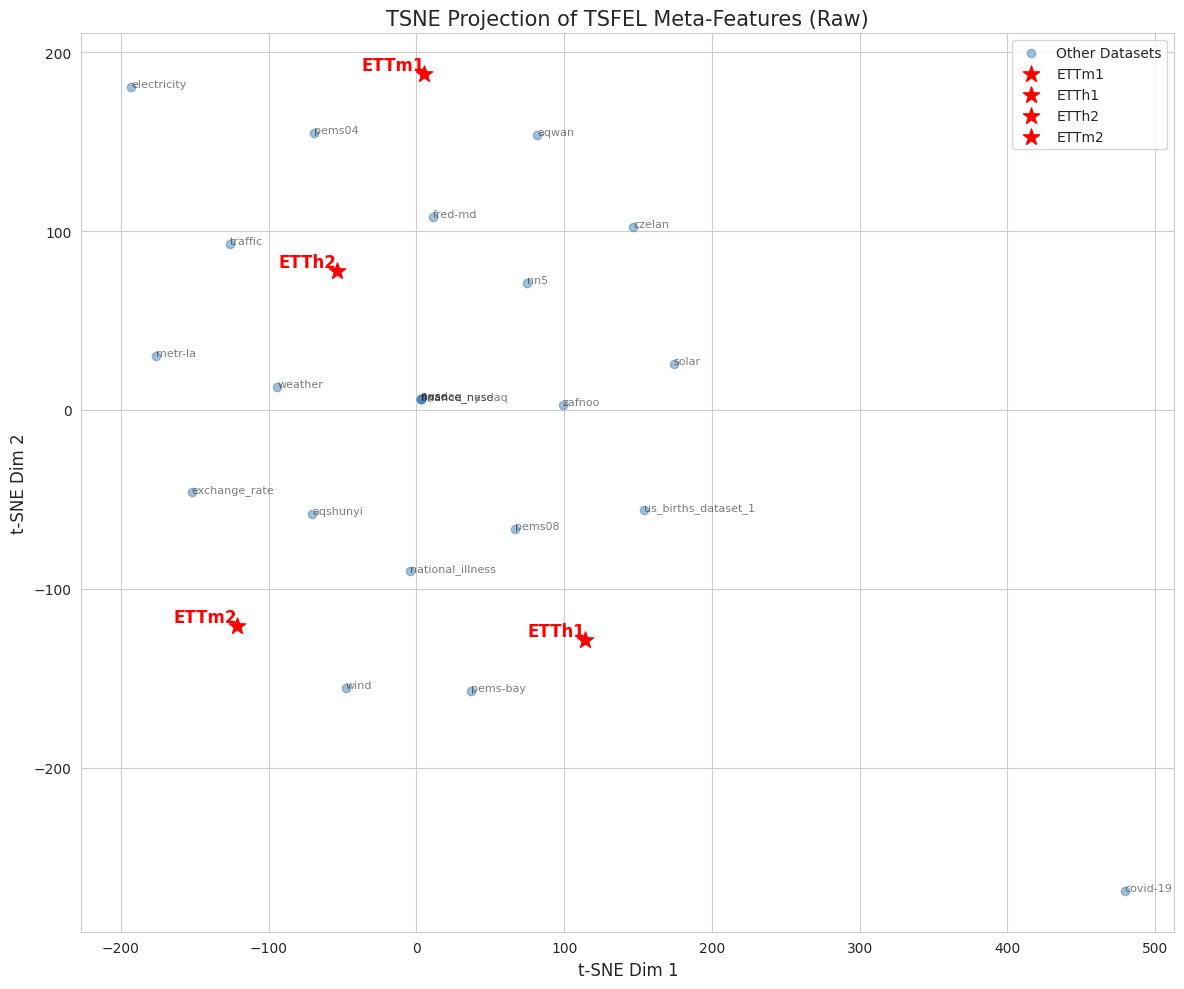

--- Visualizing TSFEL (Reduced) with TSNE ---


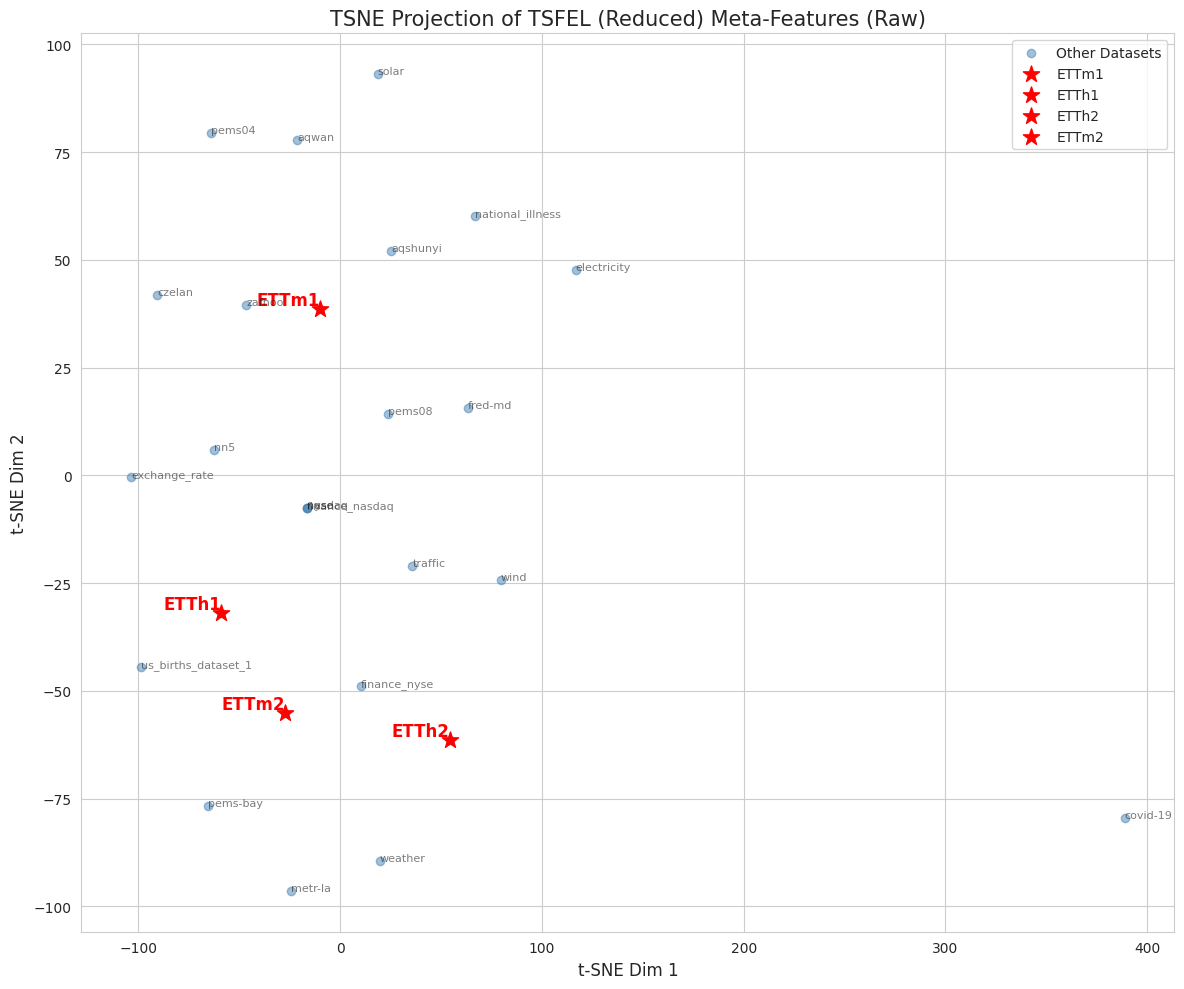

--- Visualizing TSFused with TSNE ---


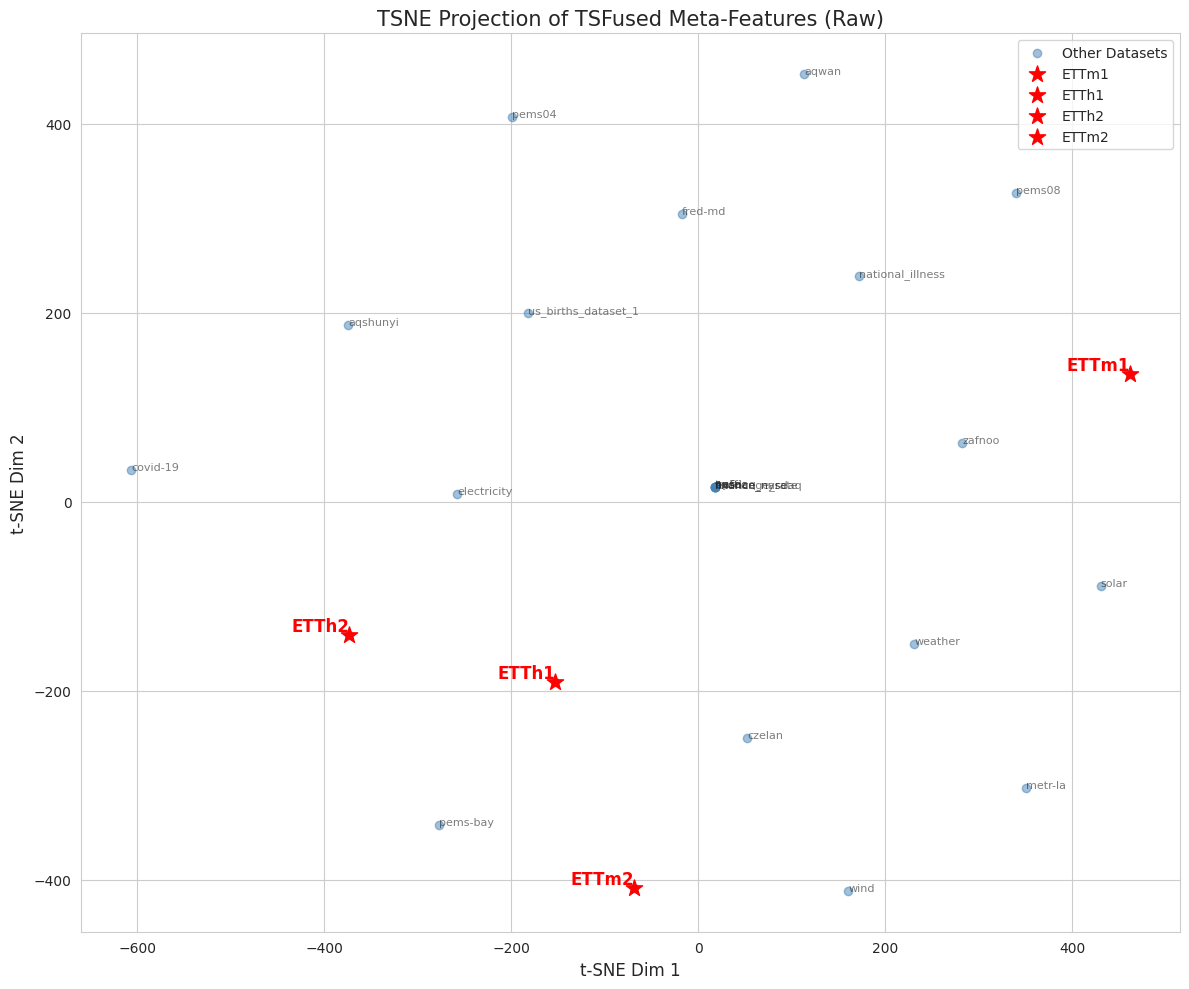

--- Visualizing TabPFN Embedding with TSNE ---


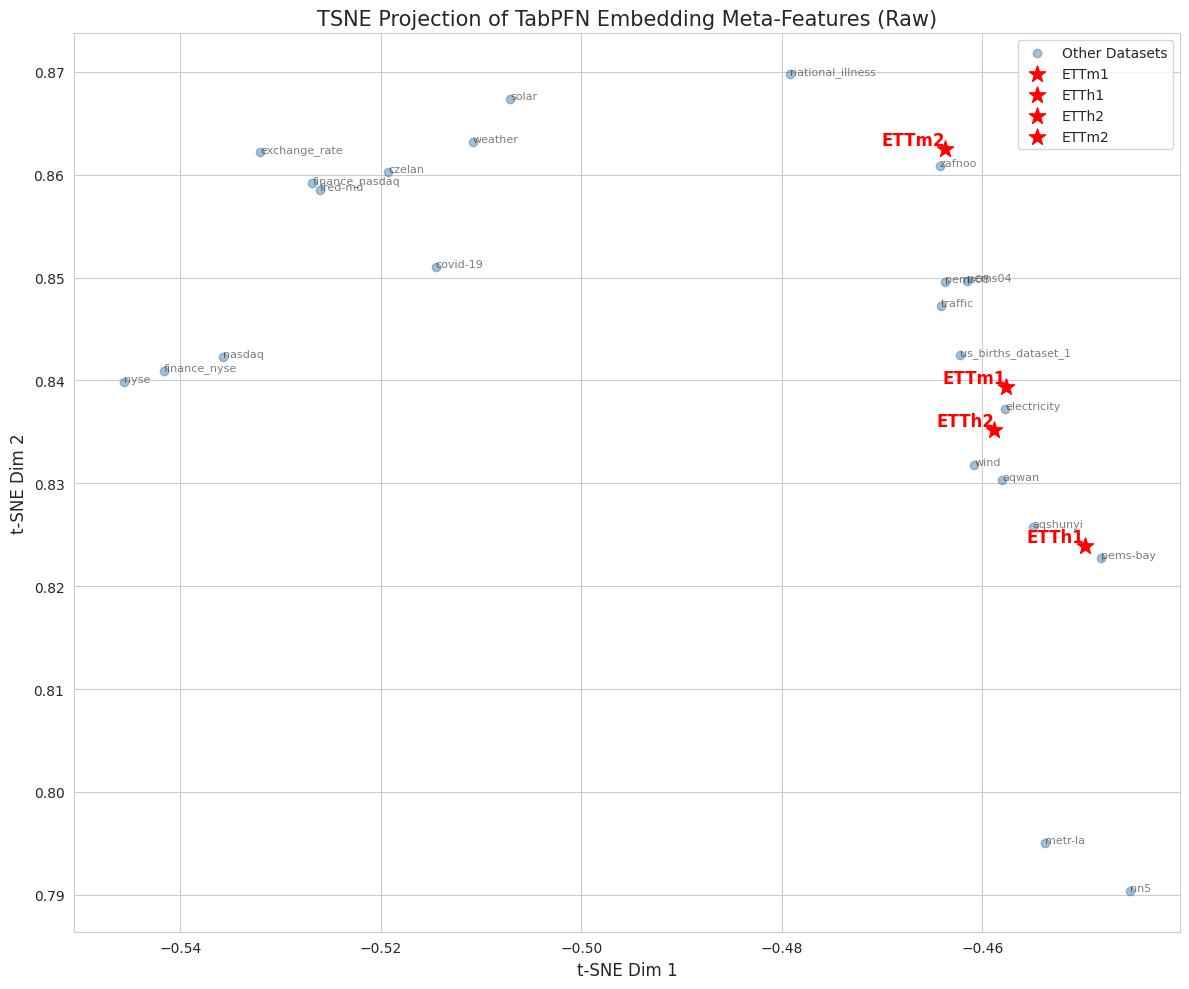

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import os
import numpy as np

def visualize_meta_features(meta_feature_files, method='tsne', standardize=True, clip=True):
    # Set style
    sns.set_style("whitegrid")
    
    for name, file_name in meta_feature_files.items():
        file_path = os.path.join(".", file_name)
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue
            
        print(f"--- Visualizing {name} with {method.upper()} ---")
        try:
            with np.load(file_path) as data:
                dataset_names = data.files
                n_samples = len(dataset_names)
                
                # Skip if no data
                if n_samples == 0:
                    print(f"No data in {file_name}")
                    continue

                # Collect features
                first_feat = data[dataset_names[0]]
                if first_feat.ndim > 1:
                    features = [data[k].flatten() for k in dataset_names]
                else:
                    features = [data[k] for k in dataset_names]
                
                X = np.stack(features)
                # Handle NaNs/Inf (replace with 0)
                X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
                
                X_processed = X
                
                # Standardization
                if standardize:
                    scaler = StandardScaler()
                    X_processed = scaler.fit_transform(X_processed)
                
                # Clipping (e.g., to [-3, 3] standard deviations to handle extreme outliers)
                if clip:
                    # Usually makes sense after standardization, but we apply if requested
                    X_processed = np.clip(X_processed, -3, 3)
                
                # Dimensionality Reduction
                if method.lower() == 'tsne':
                    # Perplexity must be less than n_samples
                    perp = min(30, n_samples - 1) if n_samples > 1 else 1
                    reducer = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate='auto')
                    X_reduced = reducer.fit_transform(X_processed)
                    xlabel, ylabel = "t-SNE Dim 1", "t-SNE Dim 2"
                else:
                    reducer = PCA(n_components=2)
                    X_reduced = reducer.fit_transform(X_processed)
                    xlabel = f"PC1 ({reducer.explained_variance_ratio_[0]:.2%})"
                    ylabel = f"PC2 ({reducer.explained_variance_ratio_[1]:.2%})"
                
                # Title string construction
                process_steps = []
                if standardize: process_steps.append("Standardized")
                if clip: process_steps.append("Clipped")
                process_str = " & ".join(process_steps) if process_steps else "Raw"

                # Plot
                plt.figure(figsize=(12, 10))
                
                # Main scatter of all points
                plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha=0.5, c='steelblue', label='Other Datasets')
                
                # Specific datasets to highlight
                target_datasets = ['ETTm1', 'ETTm2', 'ETTh1', 'ETTh2']
                
                for i, ds_name in enumerate(dataset_names):
                    # Highlight ETT datasets
                    if ds_name in target_datasets:
                        plt.scatter(X_reduced[i, 0], X_reduced[i, 1], c='red', s=150, marker='*', zorder=10, label=ds_name)
                        plt.text(X_reduced[i, 0], X_reduced[i, 1], ds_name, fontsize=12, fontweight='bold', color='red', ha='right', va='bottom')
                    # Label a few others to provide context
                    elif i % max(1, (len(dataset_names) // 15)) == 0:
                        plt.text(X_reduced[i, 0], X_reduced[i, 1], ds_name, fontsize=8, alpha=0.6)
                        
                plt.title(f"{method.upper()} Projection of {name} Meta-Features ({process_str})", fontsize=15)
                plt.xlabel(xlabel, fontsize=12)
                plt.ylabel(ylabel, fontsize=12)
                
                # Fix legend
                handles, labels = plt.gca().get_legend_handles_labels()
                by_label = dict(zip(labels, handles))
                plt.legend(by_label.values(), by_label.keys())
                
                plt.tight_layout()
                plt.show()
                
        except Exception as e:
            print(f"Failed to process {name}: {e}")

# Define the dictionary of meta-feature files to check
meta_feature_files = {
    'TSFEL': 'meta_feature_dict_tsfel.npz',
    'TSFEL (Reduced)': 'meta_feature_dict_tsfelGRP.npz',
    'TSFused': 'meta_feature_dict_tsfused.npz',
    'TabPFN Embedding': 'meta_feature_dict_tabpfn.npz'
}

# Execute visualization with t-SNE, Standardization, and Clipping
visualize_meta_features(meta_feature_files, method='tsne', standardize=False, clip=False)